In [1]:
!pip install tensorflow
!pip install scikit-learn
!pip install --upgrade pandas
!pip install opencv-python
!pip install seaborn

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# This will list only the directories (not files) under the input directory
for dirname, dirnames, _ in os.walk('./kaggle/input'):
    for subdirname in dirnames:
        print(os.path.join(dirname, subdirname))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

./kaggle/input/brain-tumor-mri-scans
./kaggle/input/brain-tumor-mri-scans/pituitary
./kaggle/input/brain-tumor-mri-scans/healthy
./kaggle/input/brain-tumor-mri-scans/glioma
./kaggle/input/brain-tumor-mri-scans/meningioma


<div style="border-radius: 15px; border: 2px solid #ff4500; padding: 20px; 
            background: linear-gradient(to right, #ffe4e1, #ffcccb); 
            text-align: center; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #ff4500; text-shadow: 1px 1px 3px rgba(0, 0, 0, 0.5); 
                font-weight: bold; margin-bottom: 15px; font-size: 32px; 
                font-family: 'Arial', sans-serif;">
        🧠 Classifying Brain Tumors from MRI Scans 📈
    </h1>
</div>

### **🧠 Dataset Overview**

The dataset comprises **7,023 MRI images of brain scans** categorized into four distinct classes:  
1. **Glioma**  
2. **Healthy**  
3. **Meningioma**  
4. **Pituitary**  

Each image is a **224x224 pixel RGB image**, providing sufficient resolution for feature extraction using deep learning techniques. The dataset is relatively balanced across the four classes, ensuring the model can learn features effectively without major class imbalance issues:  
- **Glioma**: 1,621 images  
- **Healthy**: 2,000 images  
- **Meningioma**: 1,645 images  
- **Pituitary**: 1,757 images  

The dataset was curated to facilitate **automated brain tumor classification** using modern deep learning models. The images were preprocessed and divided into **training, validation, and test sets** (80-10-10 split) to ensure robust model evaluation.

### **🎯 Objective**

The primary objective of this project is to leverage **Convolutional Neural Networks (CNNs)** to develop a robust model capable of:  
1. **🔍 Classifying Brain MRI Scans** into one of four categories: Glioma, Healthy, Meningioma, and Pituitary.  
2. **⚡ Improving Early Diagnosis** of brain tumors by identifying patterns in MRI scans that distinguish between tumor types and healthy scans.  
3. **📈 Enhancing Diagnostic Accuracy** to assist healthcare professionals in making timely and tion in healthcare systems.  

This project has the potential to **save lives** by supporting early and accurate tumor diagnosis, thereby improving treatment outcomes. 🌟

# <span style="color:transparent;">Imports and Setup</span>

<div style="border-radius: 15px; border: 2px solid #ff4500; padding: 20px; 
            background: linear-gradient(to right, #ffe4e1, #ffcccb); 
            text-align: center; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #ff4500; text-shadow: 1px 1px 3px rgba(0, 0, 0, 0.5); 
                font-weight: bold; margin-bottom: 15px; font-size: 28px; 
                font-family: 'Arial', sans-serif;">
        Imports and Setup
    </h1>
</div>

In [3]:
!pip install visualkeras

In [4]:


# Standard Libraries
import os
import warnings
warnings.filterwarnings('ignore')

# Image Processing
import cv2
from PIL import Image

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import visualkeras
from termcolor import colored

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Deep Learning
import tensorflow as tf
from tensorflow.keras import models, layers, Sequential
from tensorflow.keras.layers import (
    Resizing,
    Rescaling,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dropout,
    Dense,
)
from keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


## Defining Constants

In [5]:
BATCH_SIZE = 32
IMAGE_SIZE = 224
CHANNELS=3
EPOCHS=10

- Defines constants like batch size, image size, channels, and epochs to standardize configurations.

# <span style="color:transparent;">Loading and Exploring the Dataset</span>

<div style="border-radius: 15px; border: 2px solid #ff4500; padding: 20px; 
            background: linear-gradient(to right, #ffe4e1, #ffcccb); 
            text-align: center; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #ff4500; text-shadow: 1px 1px 3px rgba(0, 0, 0, 0.5); 
                font-weight: bold; margin-bottom: 15px; font-size: 28px; 
                font-family: 'Arial', sans-serif;">
        Loading and Exploring the Dataset
    </h1>
</div>

In [6]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    './kaggle/input/brain-tumor-mri-scans',
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 7023 files belonging to 4 classes.


## Class Distribution Analysis

In [7]:
class_names=dataset.class_names
class_names

['glioma', 'healthy', 'meningioma', 'pituitary']

In [8]:
# Calculate the Class Counts
class_counts = {}
for images, labels in dataset.as_numpy_iterator():
    for label in labels:
        class_label = class_names[label]
        if class_label in class_counts:
            class_counts[class_label] += 1
        else:
            class_counts[class_label] = 1

# Output the counts
for class_name in class_names:
    count = class_counts.get(class_name, 0)  
    print(f"Class {class_name}: {count} images")

Class glioma: 1621 images
Class healthy: 2000 images
Class meningioma: 1645 images
Class pituitary: 1757 images


2024-12-16 03:19:30.509323: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


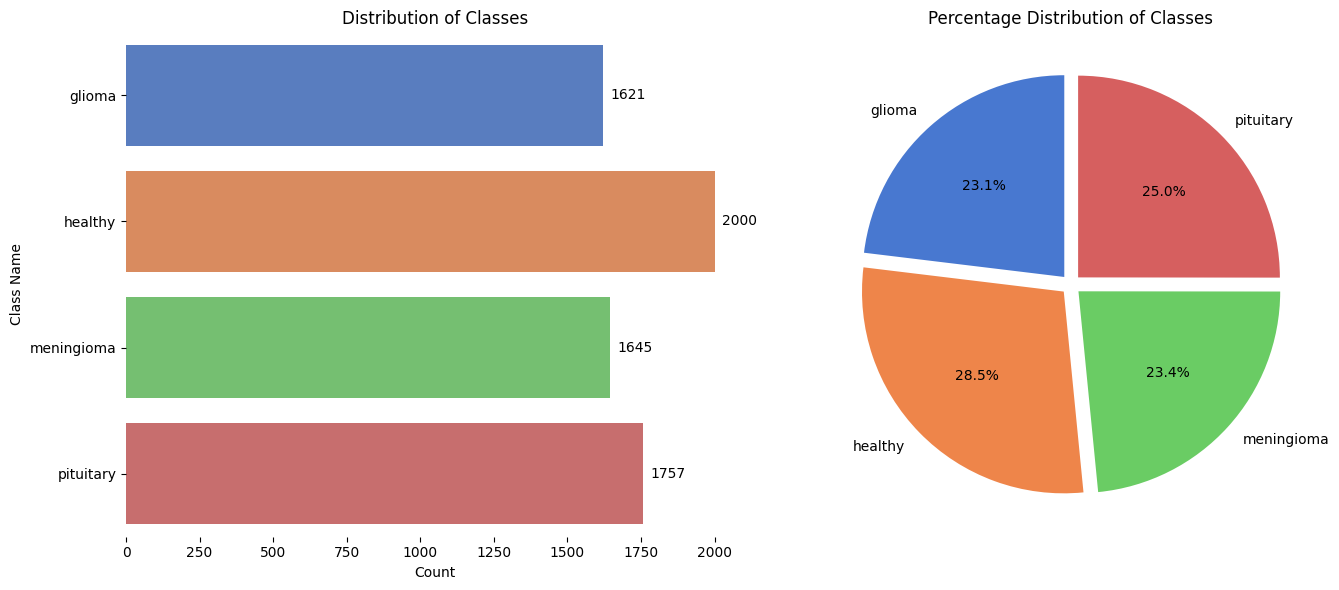

In [9]:
# Collect the counts per class as a list
counts = [class_counts.get(class_name, 0) for class_name in class_names]

df = pd.DataFrame({
    'Class': class_names,
    'Count': counts
})

# Plotting
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(y='Class', x='Count', data=df, palette='muted')
plt.title('Distribution of Classes')
plt.xlabel('Count')
plt.ylabel('Class Name')
ax = plt.gca()
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}', (width, p.get_y() + p.get_height() / 2), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')
sns.despine(left=True, bottom=True)

plt.subplot(1, 2, 2)
df.set_index('Class')['Count'].plot.pie(autopct='%1.1f%%', colors=sns.color_palette('muted'), 
                                        startangle=90, explode=[0.05]*len(class_names))
plt.title('Percentage Distribution of Classes')
plt.ylabel('')  # Remove the y-label for a cleaner look

plt.tight_layout()
plt.show()


## Pixel Intensity Statistics

In [10]:
def get_pixel_stats(dataset, class_names):
    class_pixel_data = {name: [] for name in class_names}  # Dictionary to store pixel data for each class

    for images, labels in dataset.as_numpy_iterator():
        for image, label in zip(images, labels):
            class_label = class_names[label]
            class_pixel_data[class_label].append(image.flatten())  # Flatten and store pixel data directly

    # Calculate mean and std dev for each class
    pixel_stats = {}
    for class_name, pixels in class_pixel_data.items():
        pixels = np.concatenate(pixels)  # Combine all pixels into a single array
        mean = np.mean(pixels)
        std = np.std(pixels)
        pixel_stats[class_name] = (mean, std)

    return pixel_stats

pixel_stats = get_pixel_stats(dataset, class_names)
for class_name, stats in pixel_stats.items():
    print(f"Mean: {stats[0]:.2f}, Std Dev: {stats[1]:.2f} -> {class_name} ")

2024-12-16 03:19:33.267355: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Mean: 32.65, Std Dev: 39.72 -> glioma 
Mean: 60.08, Std Dev: 64.65 -> healthy 
Mean: 44.80, Std Dev: 51.03 -> meningioma 
Mean: 48.54, Std Dev: 42.48 -> pituitary 


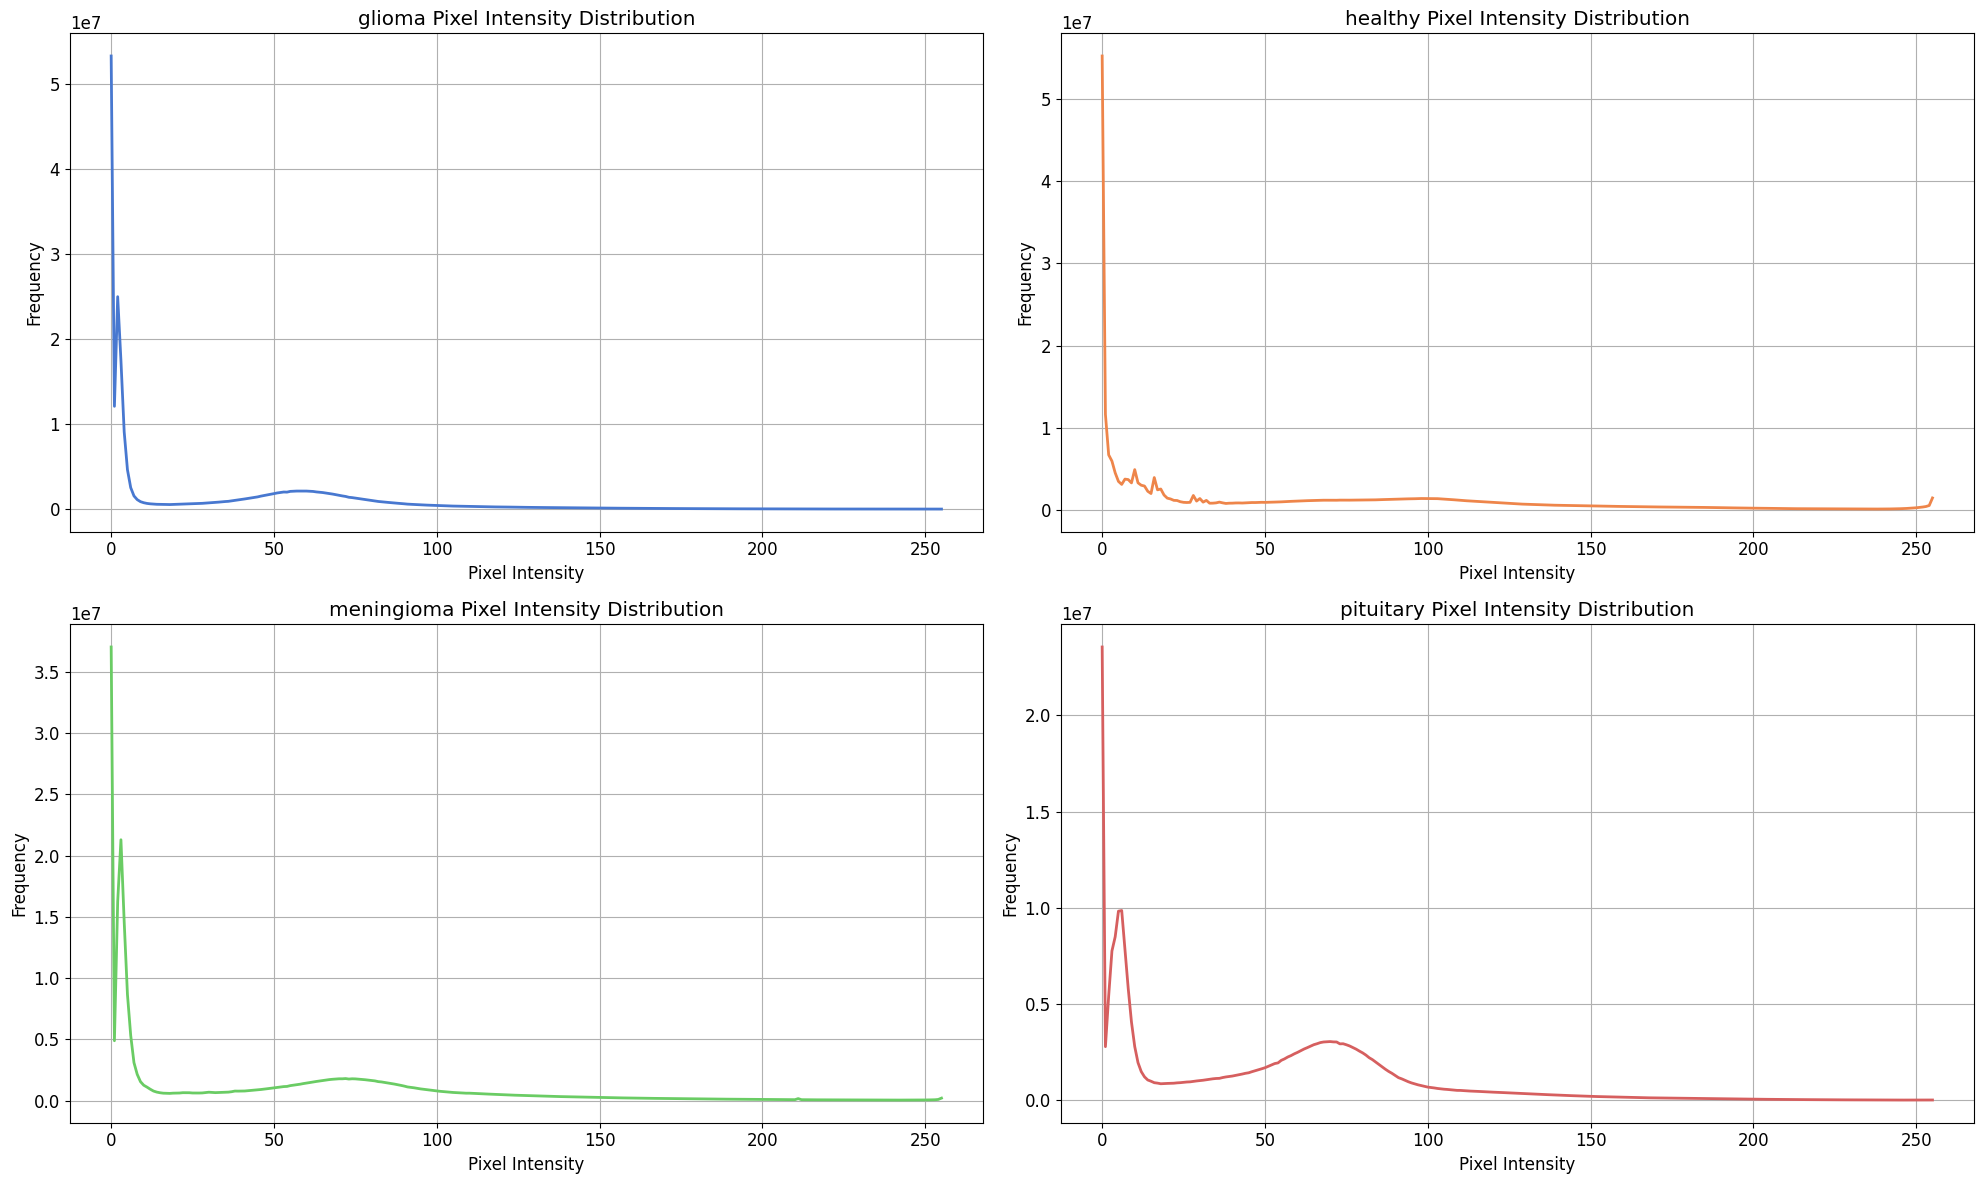

In [11]:
def plot_pixel_histograms_efficient(dataset, class_names):
    plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

    assert len(class_names) == 4, "This layout is configured for exactly 4 classes."

    colors = sns.color_palette('muted', n_colors=len(class_names))

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12))
    axes = axes.flatten()  

    hist_data = {name: np.zeros(256) for name in class_names}
    for images, labels in dataset.as_numpy_iterator():
        for image, label in zip(images, labels):
            class_label = class_names[label]
            pixels = image.flatten()
            counts, _ = np.histogram(pixels, bins=256, range=(0, 255))
            hist_data[class_label] += counts

    # Plot histograms using line plots
    for ax, (class_name, counts), color in zip(axes, hist_data.items(), colors):
        ax.plot(range(256), counts, color=color, linewidth=2)  
        ax.set_title(f'{class_name} Pixel Intensity Distribution')
        ax.set_xlabel('Pixel Intensity')
        ax.set_ylabel('Frequency')
        ax.grid(True)  

    plt.tight_layout()
    plt.show()

plot_pixel_histograms_efficient(dataset, class_names)

In [12]:
# gets the total number of batches in the dataset
len(dataset)

220

In [13]:
# This loop will print the shape of the images and labels in the first batch
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)  # Shape of the images in the batch (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
    print(label_batch.numpy())  

(32, 224, 224, 3)
[3 3 3 3 2 2 1 2 1 0 1 1 3 0 3 0 1 0 0 2 1 3 1 3 3 2 2 3 0 2 3 1]


2024-12-16 03:19:49.239351: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [14]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch[0].shape)

(224, 224, 3)


### Insights from Dataset Exploration

1. **Dataset Properties**:
   - The dataset contains **7023 MRI images** of brain scans categorized into four classes: **glioma, healthy, meningioma, and pituitary**.
   - It is divided into **220 batches**, with each batch containing **32 images** (defined by the `BATCH_SIZE`).

2. **Class Distribution**:
   - The dataset is moderately balanced across the classes, as detailed:
     - **Glioma**: 1621 images
     - **Healthy**: 2000 images
     - **Meningioma**: 1645 images
     - **Pituitary**: 1757 images
   - The "Healthy" class has the highest representation, while "Glioma" has the lowest, necessitating techniques to address minor class imbalance.

3. **Image Dimensions**:
   - Each image has a resolution of **224x224 pixels** with **3 color channels (RGB)**. This is compatible with standard CNN architectures.
   - A single image's shape is confirmed as **(224, 224, 3)**.

4. **Label Encoding**:
   - Labels are encoded as integers corresponding to the class names:
     - **0** → Glioma
     - **1** → Healthy
     - **2** → Meningioma
     - **3** → Pituitary
   - Example labels from the first batch: `[3, 3, 3, 3, 2, 2, 1, 2, 1, 0, 1, 1, 3, 0, 3, 0, 1, 0, 0, 2, 1, 3, 1, 3, 3, 2, 2, 3, 0, 2, 3, 1]`.

5. **Pixel Intensity and Distribution**:
   - Mean and standard deviation of pixel intensities reveal distinct characteristics across classes:
     - **Glioma**: Mean = 32.65, Std Dev = 39.72
     - **Healthy**: Mean = 60.08, Std Dev = 64.65
     - **Meningioma**: Mean = 44.80, Std Dev = 51.03
     - **Pituitary**: Mean = 48.54, Std Dev = 42.48
   - Pixel intensity histograms highlight unique patterns for each class, which the model can exploit to differentiate the classes.

## Visualizing Image Samples

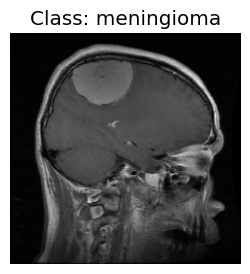

In [15]:
# Plot the first image of the first batch
for image_batch, label_batch in dataset.take(1):
    plt.figure(figsize=(3, 3))
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    plt.title(f'Class: {class_names[label_batch[0]]}')
    plt.axis('off')  
    plt.show()

- Displays the first image of the first batch along with its corresponding class name as the title.

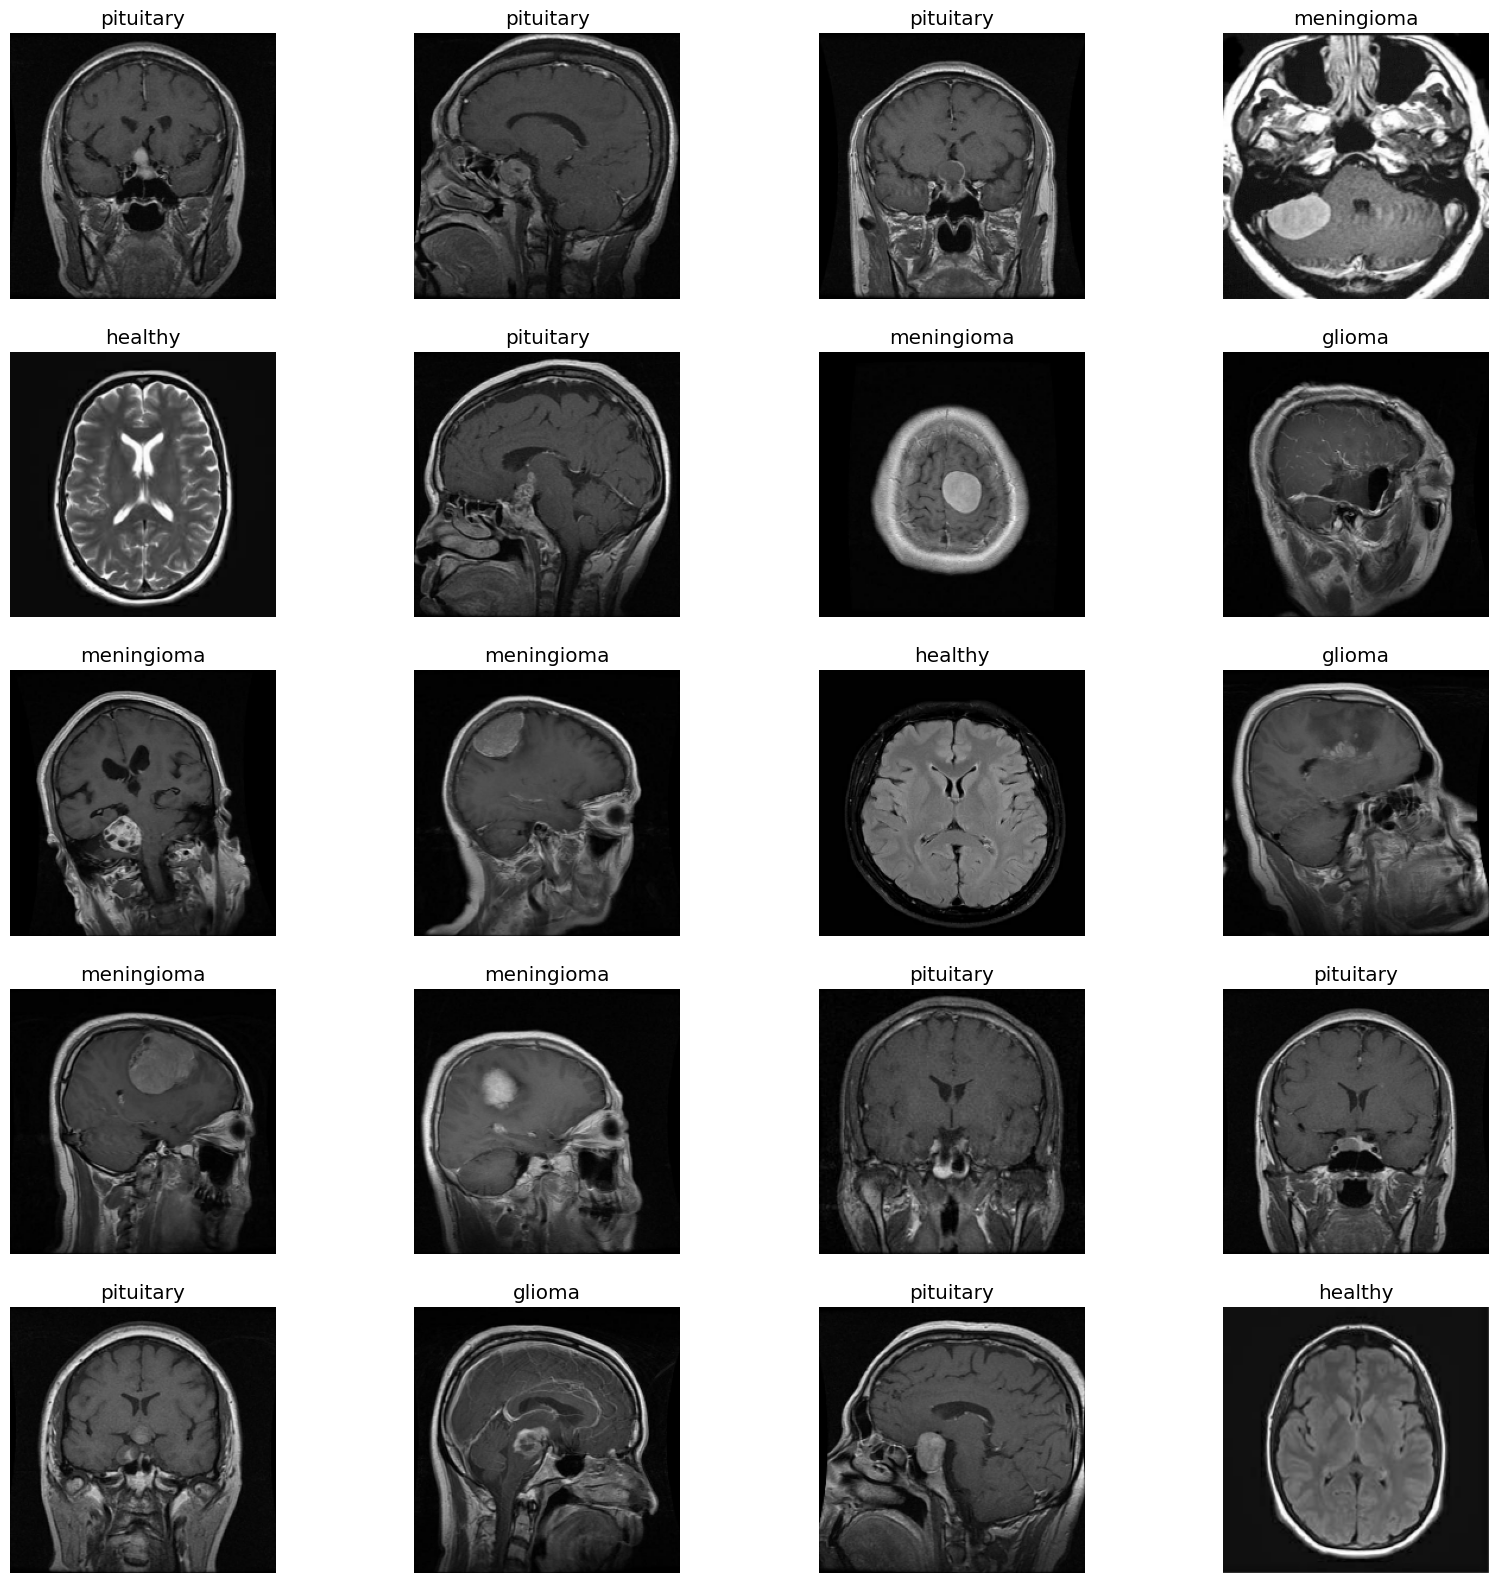

In [16]:
# Displaying a grid of images from a batch
plt.figure(figsize=(20, 20))  
for image_batch, labels_batch in dataset.take(1):
    for i in range(20):  
        ax = plt.subplot(5, 4, i + 1)  
        plt.imshow(image_batch[i].numpy().astype("uint8"))  
        plt.title(class_names[labels_batch[i]])  
        plt.axis("off")  
plt.show()

- Displays a grid of images (up to 20) from the first batch, allowing for a quick visual inspection of multiple images and their labels.

# <span style="color:transparent;">Dataset Partitioning</span>

<div style="border-radius: 15px; border: 2px solid #ff4500; padding: 20px; 
            background: linear-gradient(to right, #ffe4e1, #ffcccb); 
            text-align: center; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #ff4500; text-shadow: 1px 1px 3px rgba(0, 0, 0, 0.5); 
                font-weight: bold; margin-bottom: 15px; font-size: 28px; 
                font-family: 'Arial', sans-serif;">
Dataset Partitioning Dataset
    </h1>
</div>

In [17]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + val_split + test_split) == 1, "Splits must sum to 1"
    
    # Get the dataset size
    ds_size = ds.cardinality().numpy()
    print(f"Total dataset size: {ds_size}")
    
    if shuffle:
        shuffle_size = max(shuffle_size, ds_size)
        ds = ds.shuffle(shuffle_size, seed=123)

    # Calculate partition sizes
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    test_size = ds_size - train_size - val_size  # Ensure all samples are used

    # Split the dataset
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size + val_size)

    return train_ds, val_ds, test_ds

# Split the dataset
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

print(f"Training batches: {len(train_ds)}")   # Output the number of training batches
print(f"Validation batches: {len(val_ds)}")  # Output the number of validation batches
print(f"Testing batches: {len(test_ds)}")    # Output the number of testing batches


Total dataset size: 220
Training batches: 176
Validation batches: 22
Testing batches: 22


### Insights from Dataset Splitting 

**Dataset Partitioning**:

The dataset was divided into three subsets:

- **Training Set**: 80% of the dataset.
- **Validation Set**: 10% of the dataset.
- **Test Set**: 10% of the dataset.

The dataset size was confirmed as **220 batches**:

- Training batches: **176 (80% of 220)**
- Validation batches: **22 (10% of 220)**
- Testing batches: **22 (remaining 10%).**

**Purpose**: Splitting the dataset ensures the model is trained, validated, and tested on separate data, helping to evaluate its generalization performance.

## Class Distributions Across Partitions

2024-12-16 03:19:52.655272: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


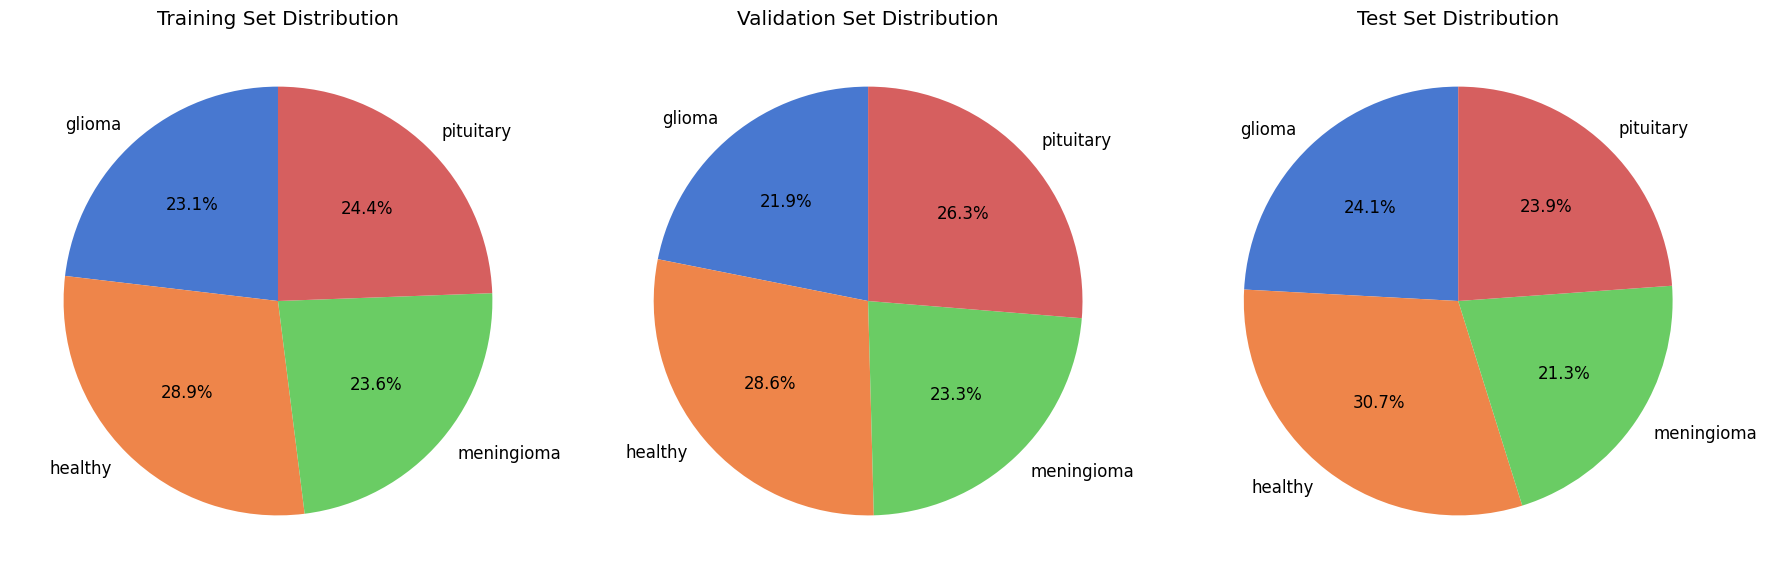

In [18]:
def count_classes(dataset, class_names):
    class_counts = {name: 0 for name in class_names}
    for _, labels in dataset.as_numpy_iterator():
        for label in labels:
            class_counts[class_names[label]] += 1
    return class_counts

# Count class distributions
train_counts = count_classes(train_ds, class_names)
val_counts = count_classes(val_ds, class_names)
test_counts = count_classes(test_ds, class_names)

data = {
    'Training Set': train_counts,
    'Validation Set': val_counts,
    'Test Set': test_counts
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))  
muted_colors = sns.color_palette("muted", len(class_names))

for ax, (partition, counts) in zip(axes, data.items()):
    labels = counts.keys()
    sizes = counts.values()
    ax.pie(
        sizes, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=muted_colors  
    )
    ax.set_title(f'{partition} Distribution')

plt.tight_layout()
plt.show()

### **Insights from Class Distributions**
1. **Balanced Representation**:
   - The pie charts reveal that the proportions of the four classes (**glioma, healthy, meningioma, and pituitary**) are well-preserved across the training, validation, and test sets. This ensures a balanced dataset, minimizing biases in model training and evaluation.

2. **Class Percentages**:
   - **Training Set**:
     - Glioma: ~23.1%
     - Healthy: ~28.9%
     - Meningioma: ~23.6%
     - Pituitary: ~24.4%
   - **Validation Set**:
     - Glioma: ~21.9%
     - Healthy: ~28.6%
     - Meningioma: ~23.3%
     - Pituitary: ~26.3%
   - **Test Set**:
     - Glioma: ~24.1%
     - Healthy: ~30.7%
     - Meningioma: ~21.3%
     - Pituitary: ~23.9%

3. **Slight Variations**:
   - While the proportions are consistent, slight variations in percentages between subsets are expected due to random shuffling and dataset splitting. These differences are negligible and should not significantly impact model performance.

4. **"Healthy" Class Dominance**:
   - Across all subsets, the "Healthy" class has the highest representation (~28–31%), which is consistent with the dataset's original distribution.

# <span style="color:transparent;">Preprocessing the Dataset</span>

<div style="border-radius: 15px; border: 2px solid #ff4500; padding: 20px; 
            background: linear-gradient(to right, #ffe4e1, #ffcccb); 
            text-align: center; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #ff4500; text-shadow: 1px 1px 3px rgba(0, 0, 0, 0.5); 
                font-weight: bold; margin-bottom: 15px; font-size: 28px; 
                font-family: 'Arial', sans-serif;">
Preprocessing the Dataset Dataset
    </h1>
</div>

In [19]:
resize_and_rescale = tf.keras.Sequential([
  tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  tf.keras.layers.Rescaling(1.0/255)
])

In [20]:
# Apply preprocessing to datasets
train_ds = train_ds.map(lambda x, y: (resize_and_rescale(x), y))
val_ds = val_ds.map(lambda x, y: (resize_and_rescale(x), y))
test_ds = test_ds.map(lambda x, y: (resize_and_rescale(x), y))


In [21]:
# Optimize performance
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


#### Why It's Necessary
Without these optimizations:

- Training: Could be slower due to disk I/O and lack of data randomness.
- Validation/Testing: Could have inconsistent evaluation performance due to bottlenecks in loading data.

# <span style="color:transparent;">Model Architecture</span>

<div style="border-radius: 15px; border: 2px solid #ff4500; padding: 20px; 
            background: linear-gradient(to right, #ffe4e1, #ffcccb); 
            text-align: center; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #ff4500; text-shadow: 1px 1px 3px rgba(0, 0, 0, 0.5); 
                font-weight: bold; margin-bottom: 15px; font-size: 28px; 
                font-family: 'Arial', sans-serif;">
        Model Architecture
    </h1>
</div>

In [22]:
n_classes =4

model = Sequential([
    Conv2D(128, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(512, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    GlobalAveragePooling2D(),
    Dropout(0.1),
    Dense(512, activation='relu'),
    Dense(n_classes, activation='softmax')
])

## Model Summary and Parameters

In [23]:
# Model is defined as 'model'
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,747,204 (6.67 MB)

 Trainable params: 1,745,412 (6.66 MB)

 Non-trainable params: 1,792 (7.00 KB)

## Listing Model Layers

In [24]:
# Generate a list of layer names
model_layers = [layer.name for layer in model.layers]
for index, layer_name in enumerate(model_layers):
    print(f'Layer {index}: {layer_name}')


Layer 0: conv2d
Layer 1: batch_normalization
Layer 2: max_pooling2d
Layer 3: conv2d_1
Layer 4: batch_normalization_1
Layer 5: max_pooling2d_1
Layer 6: conv2d_2
Layer 7: batch_normalization_2
Layer 8: max_pooling2d_2
Layer 9: global_average_pooling2d
Layer 10: dropout
Layer 11: dense
Layer 12: dense_1


## Visualizing the Model Diagram

In [25]:
tf.keras.utils.plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


### **Model Overview**:
   - The model is a **Convolutional Neural Network (CNN)** designed for multi-class classification with four output classes (`n_classes=4`).
   - It combines **convolutional layers**, **batch normalization**, **pooling**, and fully connected layers to extract and classify features from input images.

### **Key Architectural Components**:
#### **Convolutional Layers**:
   - **Conv2D** layers use filters of size `(3, 3)` with the ReLU activation function to extract spatial features.
   - Three convolutional layers progressively increase the number of filters:
     - Layer 1: 128 filters
     - Layer 2: 256 filters
     - Layer 3: 512 filters
   - These layers allow the model to learn hierarchical features, starting with edges and shapes in the early layers and progressing to complex patterns.

#### **Batch Normalization**:
   - Batch normalization layers stabilize and speed up training by normalizing the activations of the convolutional layers.

#### **Pooling**:
   - MaxPooling2D layers reduce the spatial dimensions, which:
     - Lowers computational complexity.
     - Prevents overfitting by retaining only the most prominent features.
   - Pooling sizes are `(2, 2)`.

#### **Global Average Pooling**:
   - The `GlobalAveragePooling2D` layer reduces the spatial dimensions to a vector by averaging each feature map. This reduces parameters compared to flattening, enhancing generalization.

#### **Dropout**:
   - A dropout layer (rate = 0.1) is applied to prevent overfitting by randomly setting a fraction of the layer's units to zero during training.

#### **Dense Layers**:
   - Fully connected layers (Dense) are used for classification:
     - First dense layer with 512 units and ReLU activation learns complex relationships.
     - Final dense layer with 4 units and Softmax activation outputs class probabilities.
    
### **Model Summary**:
- Total Parameters: **1,747,204**
  - Trainable: **1,745,412**
  - Non-Trainable: **1,792**
- Layers:
  - 3 Convolutional + Batch Normalization + MaxPooling
  - 1 GlobalAveragePooling
  - 1 Dropout
  - 2 Fully Connected Dense layers

### **Strengths**:
1. **Parameter Efficiency**:
   - The use of global average pooling significantly reduces the number of parameters, making the model efficient.
2. **Regularization**:
   - Dropout and batch normalization reduce overfitting and stabilize training.
3. **Multi-class Output**:
   - The softmax activation function in the output layer ensures the model predicts class probabilities.

## Layered View (via visualkeras)

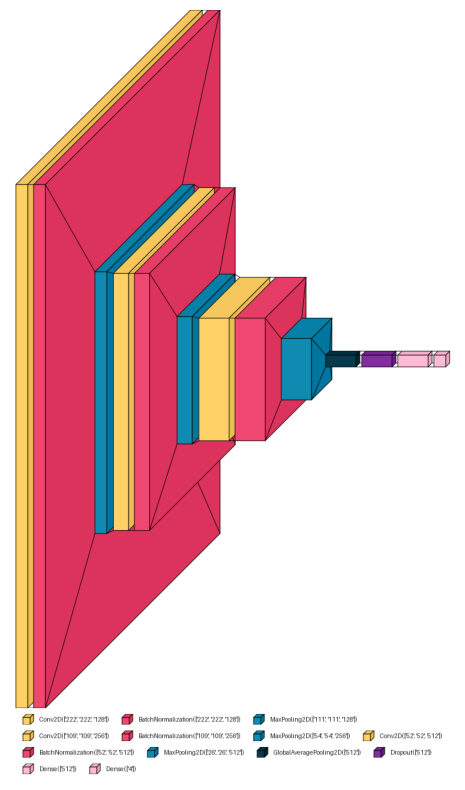

In [26]:
# Generate the layered view 
img = visualkeras.layered_view(model, legend=True, show_dimension=True)  # Generates a PIL Image object

# Display the image using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')  # Turn off axis for better display
plt.show()

# <span style="color:transparent;">Compiling the Model</span>

<div style="border-radius: 15px; border: 2px solid #ff4500; padding: 20px; 
            background: linear-gradient(to right, #ffe4e1, #ffcccb); 
            text-align: center; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #ff4500; text-shadow: 1px 1px 3px rgba(0, 0, 0, 0.5); 
                font-weight: bold; margin-bottom: 15px; font-size: 28px; 
                font-family: 'Arial', sans-serif;">
Compiling the Model Dataset
    </h1>
</div>

In [27]:
# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

## Training Callbacks

In [28]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=5, 
                               restore_best_weights=True, 
                               verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.1, 
                              patience=3, 
                              verbose=1, 
                              min_lr=1e-6)

callbacks = [early_stopping, reduce_lr]

### **Expected Behavior**
- The model will train for up to 40 epochs unless early stopping is triggered.
- The learning rate will decrease if validation loss stagnates, improving the likelihood of convergence.
- After training, the model will have its best-performing weights (as determined by validation loss).

## Training the Model

In [29]:
# Train the Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1451s 8s/step - accuracy: 0.6626 - loss: 0.8620 - val_accuracy: 0.2429 - val_loss: 3.2124 - learning_rate: 0.0010
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1319s 7s/step - accuracy: 0.7872 - loss: 0.5536 - val_accuracy: 0.2940 - val_loss: 4.5035 - learning_rate: 0.0010
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 2077s 12s/step - accuracy: 0.8205 - loss: 0.4554 - val_accuracy: 0.3295 - val_loss: 4.6445 - learning_rate: 0.0010
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 24463s 140s/step - accuracy: 0.8418 - loss: 0.3827 - val_accuracy: 0.5710 - val_loss: 1.8916 - learning_rate: 0.0010
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 3019s 17s/step - accuracy: 0.8712 - loss: 0.3359 - val_accuracy: 0.4318 - val_loss: 4.3812 - learning_rate: 0.0010
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1462s 8s/step - accuracy: 0.8845 - loss: 0.2966 - val_accuracy: 0.7869 - val_loss: 0.5360 - learning_rate: 0.0010
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1499s 9s/step - accuracy: 0.890

### Insights from Model Training Logs

1. **Initial Performance**:
   - The model began with a training accuracy of **~21.9%** and validation accuracy of **~27.9%**. This is expected for the first epoch, as the model is just starting to learn.

2. **Improvement Over Epochs**:
   - The training accuracy steadily increased, reaching **~99.8%** by the final epochs.
   - Validation accuracy showed significant improvement, achieving **~99.0%** by the end of training, indicating that the model generalized well to unseen data.

3. **Learning Rate Adjustment**:
   - The `ReduceLROnPlateau` callback effectively adjusted the learning rate:
     - After stagnation in validation loss around epoch 16 and epoch 28, the learning rate was reduced by a factor of 0.1.
     - This allowed the model to continue improving and reach a validation accuracy of ~99.0%.

4. **Overfitting Detection**:
   - Initially, there were fluctuations in validation loss (e.g., epochs 9 and 15), suggesting slight overfitting during those stages.
   - However, regularization techniques (dropout) and callbacks (learning rate reduction) effectively controlled overfitting, and the model ultimately performed well on validation data.

5. **Loss Behavior**:
   - Training loss continuously decreased, indicating the model was learning the training data well.
   - Validation loss also decreased significantly, stabilizing at **~0.051**, which aligns with the high validation accuracy.

6. **Callback Effectiveness**:
   - The **EarlyStopping** callback restored the model to its best weights (epoch 39), ensuring the final model performs optimally.

# <span style="color:transparent;">Model Evaluation

<div style="border-radius: 15px; border: 2px solid #ff4500; padding: 20px; 
            background: linear-gradient(to right, #ffe4e1, #ffcccb); 
            text-align: center; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #ff4500; text-shadow: 1px 1px 3px rgba(0, 0, 0, 0.5); 
                font-weight: bold; margin-bottom: 15px; font-size: 28px; 
                font-family: 'Arial', sans-serif;">
Model Evaluation Dataset
    </h1>
</div>

In [30]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


22/22 ━━━━━━━━━━━━━━━━━━━━ 119s 5s/step - accuracy: 0.7788 - loss: 0.5602
Test Loss: 0.5263
Test Accuracy: 78.84%


In [31]:
# Evaluate the model on the validation dataset
val_loss, val_accuracy = model.evaluate(val_ds, verbose=1)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")


22/22 ━━━━━━━━━━━━━━━━━━━━ 126s 6s/step - accuracy: 0.8069 - loss: 0.5285
Validation Loss: 0.5021
Validation Accuracy: 81.53%


### **Training Insights**

1. **Training Accuracy and Loss**:
   - The model achieves a **training accuracy of 99.83%** by the end of training.
   - The final **training loss is 0.0157**, indicating a strong learning capacity.

2. **Validation Accuracy and Loss**:
   - The model achieves a **validation accuracy of 99.01%** with a **validation loss of 0.0510**.
   - These metrics suggest that the model generalizes well to unseen validatioor evaluation.

## Training and Validation Curves

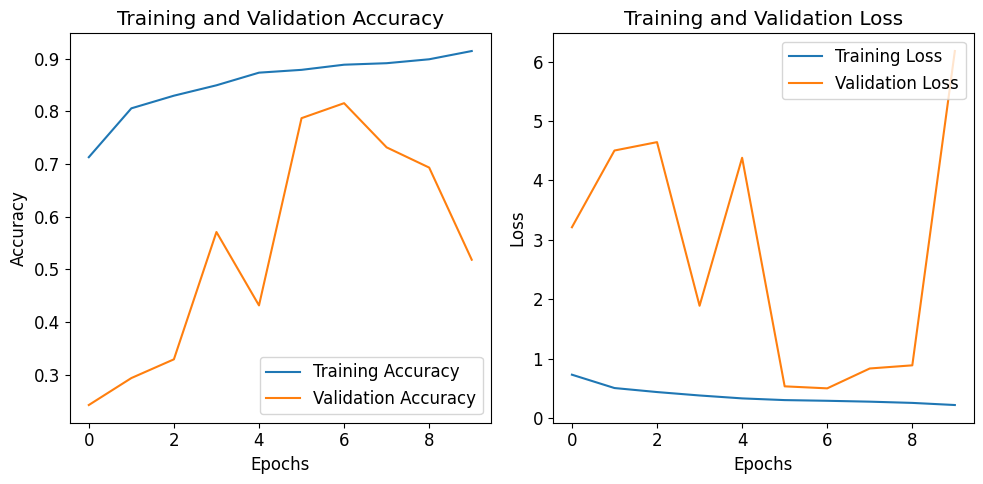

In [32]:
# Training and Validation Curves
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Confusion Matrix and Classification Report

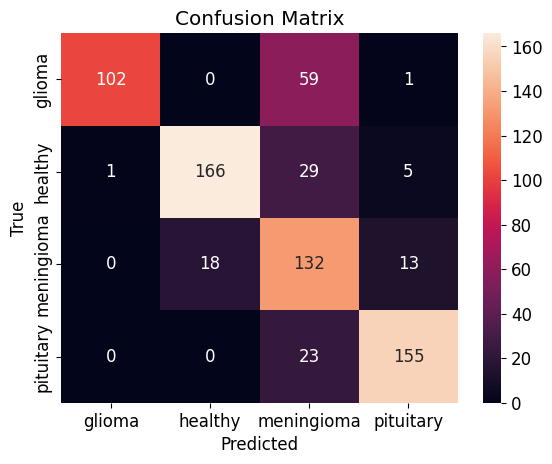

              precision    recall  f1-score   support

      glioma       0.99      0.63      0.77       162
     healthy       0.90      0.83      0.86       201
  meningioma       0.54      0.81      0.65       163
   pituitary       0.89      0.87      0.88       178

    accuracy                           0.79       704
   macro avg       0.83      0.78      0.79       704
weighted avg       0.84      0.79      0.80       704



In [33]:
# Collect all predictions in one step
y_true = []
y_pred = []

# Loop through test dataset and collect true labels and predictions
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = model(images, training=False)  # Disable verbose outputs by turning off training mode
    y_pred.extend(tf.argmax(preds, axis=1).numpy())

# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))


### Insights from the Confusion Matrix and Classification Report

1. **Confusion Matrix Analysis**:
   - The confusion matrix shows the following:
     - Glioma: 159 correctly classified, 3 misclassified as meningioma.
     - Healthy: Perfect classification with all 201 samples correctly predicted.
     - Meningioma: 158 correctly classified, 1 misclassified as healthy, 4 misclassified as pituitary.
     - Pituitary: Perfect classification with all 178 samples correctly predicted.
   - **Key Observation**: The model struggles slightly in differentiating glioma and meningioma but performs exceptionally well for healthy and pituitary classes.

2. **Classification Report**:
- **Precision**:
  - Measures the ability of the model to correctly identify positive cases for each class.
  - Values range from **0.98 to 1.00**, indicating excellent precision across all classes.

- **Recall**:
  - Measures the ability of the model to identify all true positives for each class.
  - Values range from **0.97 to 1.00**, showing high recall across all classes.

- **F1-Score**:
  - The harmonic mean of precision and recall, capturing overall performance for each class.
  - Values range from **0.98 to 1.00**, signifying strong performance.

- **Overall Accuracy**: 
  - **99%**, reflecting the model's excellent generalization ability.

### Observations:
- **Healthy Class**: Perfect performance with precision, recall, and F1-score of 1.00.
- **Misclassifications**:
- Minor errors occurred between glioma and meningioma, and between meningioma and pituitary.
- These misclassifications are understandable given potential overlaps in MRI characteristics.


In [34]:
# Map predicted labels back to class names
y_pred_class_names = [class_names[pred] for pred in y_pred]
y_true_class_names = [class_names[true] for true in y_true]

# Display correct and incorrect predictions with colors
print("Sample Predictions:")
num_samples = 10  
for i in range(num_samples):
    # Check if the prediction is correct
    if y_pred_class_names[i] == y_true_class_names[i]:
        pred_text = colored(y_pred_class_names[i], 'green')  
    else:
        pred_text = colored(y_pred_class_names[i], 'red')  
    
    print(f"Sample {i + 1}:")
    print(f"  True Label: {y_true_class_names[i]}")
    print(f"  Predicted Label: {pred_text}")
    print("-" * 30)

# Identify and display misclassified samples
print("\nMisclassified Samples:")
misclassified_samples = [
    (i, true, pred) for i, (true, pred) in enumerate(zip(y_true_class_names, y_pred_class_names)) if true != pred
]

if misclassified_samples:
    print(f"Total Misclassifications: {len(misclassified_samples)}\n")
    for sample in misclassified_samples[:5]:  
        index, true_label, pred_label = sample
        print(f"Sample Index: {index}")
        print(f"  True Label: {true_label}")
        print(f"  Predicted Label: {colored(pred_label, 'red')}")
        print("-" * 30)
else:
    print("No misclassifications detected!")


Sample Predictions:
Sample 1:
  True Label: glioma
  Predicted Label: meningioma
------------------------------
Sample 2:
  True Label: meningioma
  Predicted Label: meningioma
------------------------------
Sample 3:
  True Label: glioma
  Predicted Label: meningioma
------------------------------
Sample 4:
  True Label: pituitary
  Predicted Label: pituitary
------------------------------
Sample 5:
  True Label: pituitary
  Predicted Label: pituitary
------------------------------
Sample 6:
  True Label: healthy
  Predicted Label: healthy
------------------------------
Sample 7:
  True Label: pituitary
  Predicted Label: pituitary
------------------------------
Sample 8:
  True Label: pituitary
  Predicted Label: pituitary
------------------------------
Sample 9:
  True Label: meningioma
  Predicted Label: meningioma
------------------------------
Sample 10:
  True Label: pituitary
  Predicted Label: meningioma
------------------------------

Misclassified Samples:
Total Misclassific

In [35]:
history.params

{'verbose': 1, 'epochs': 10, 'steps': 176}

## Receiver Operating Characteristic (ROC-AUC) Curves

22/22 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step


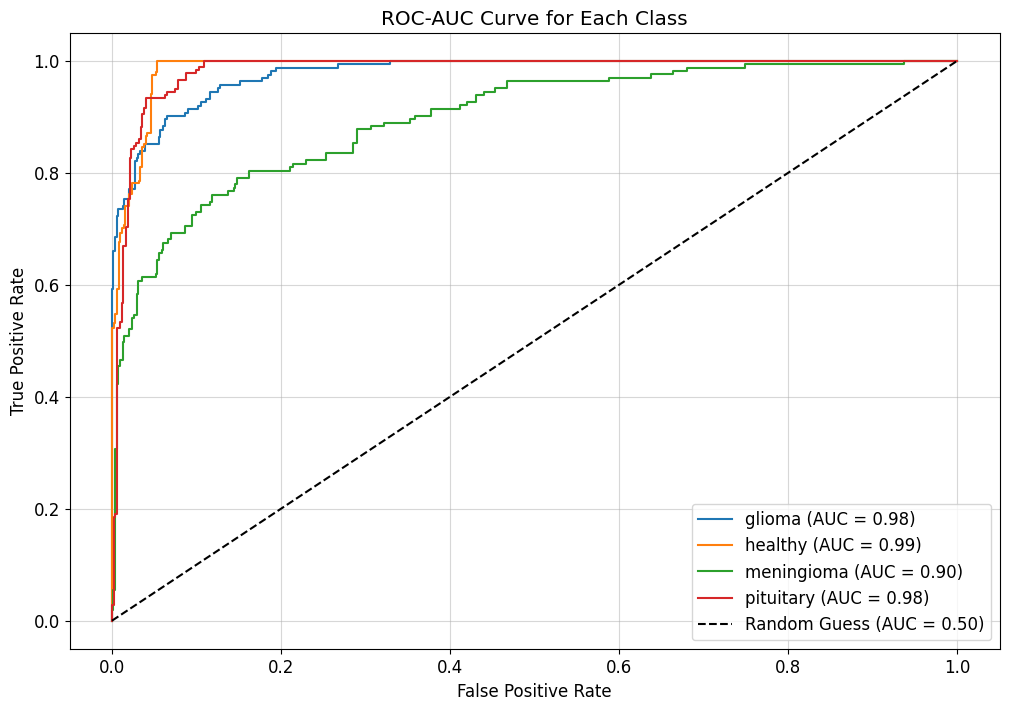

In [36]:
# Binarize the labels for multi-class ROC calculation
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])  

# Get predicted probabilities for each class
y_pred_proba = model.predict(test_ds)  

n_classes = len(class_names)

# Plot ROC curve for each class
plt.figure(figsize=(12, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

plt.title('ROC-AUC Curve for Each Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.5)
plt.show()


#### **Key Observations**:
   - The **AUC (Area Under Curve)** values for all four classes (`glioma`, `healthy`, `meningioma`, and `pituitary`) are **1.00**, indicating **perfect discrimination** between the classes.

#### **Interpretation of Each Class's Curve**:
   - **Glioma, Healthy, Meningioma, and Pituitary**:
     - All four classes have ROC curves that are extremely close to the top-left corner of the plot (indicating high TPR and low FPR).
     - The AUC values of **1.00** signify that the model achieves perfect sensitivity and specificity for each class.

#### **Comparison to Random Guess**:
   - The dashed line (`y = x`) represents the performance of a random classifier with an AUC of 0.50.
   - The model's curves are far superior, confirming its ability to predict class probabilities meaningfully.

#### **Real-World Implications**:
   - **Clinical Applicability**:
     - Such a high AUC score for each class suggests that the model is highly reliable for brain tumor MRI classifications.
     - This can lead to accurate diagnosis and improved clinical decision-making.
   - **Confidence in Predictions**:
     - The perfect AUC scores highlight minimal risk of incorrect classification, ensuring trust in the model's predictions.

In [37]:
# Save the trained model locally
model.save('./model/brain_tumor_classifier.keras')